Iniciando simulación del SOA...
Simulando propagación en SOA...
BER = 6.104e-05 | Offset Óptimo: 16
Generando gráficas ANTES del modelo...


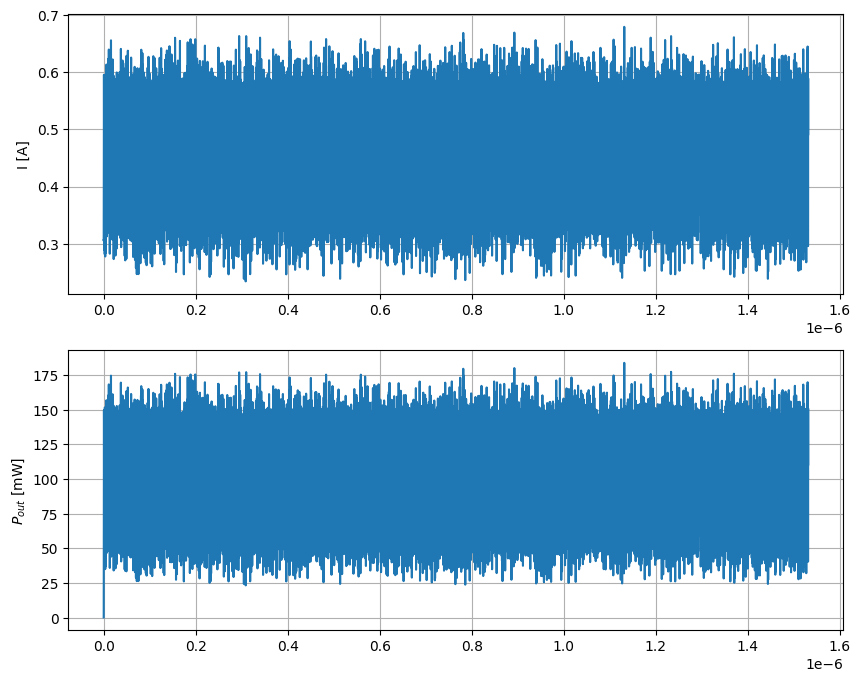

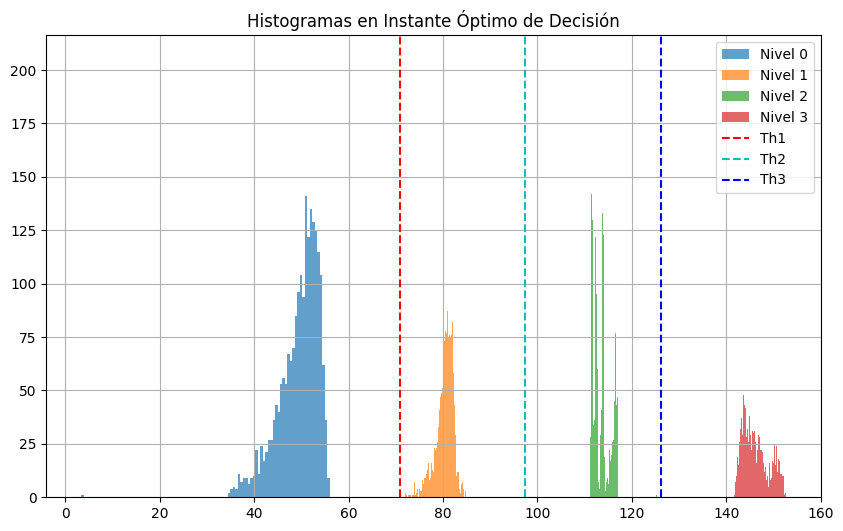

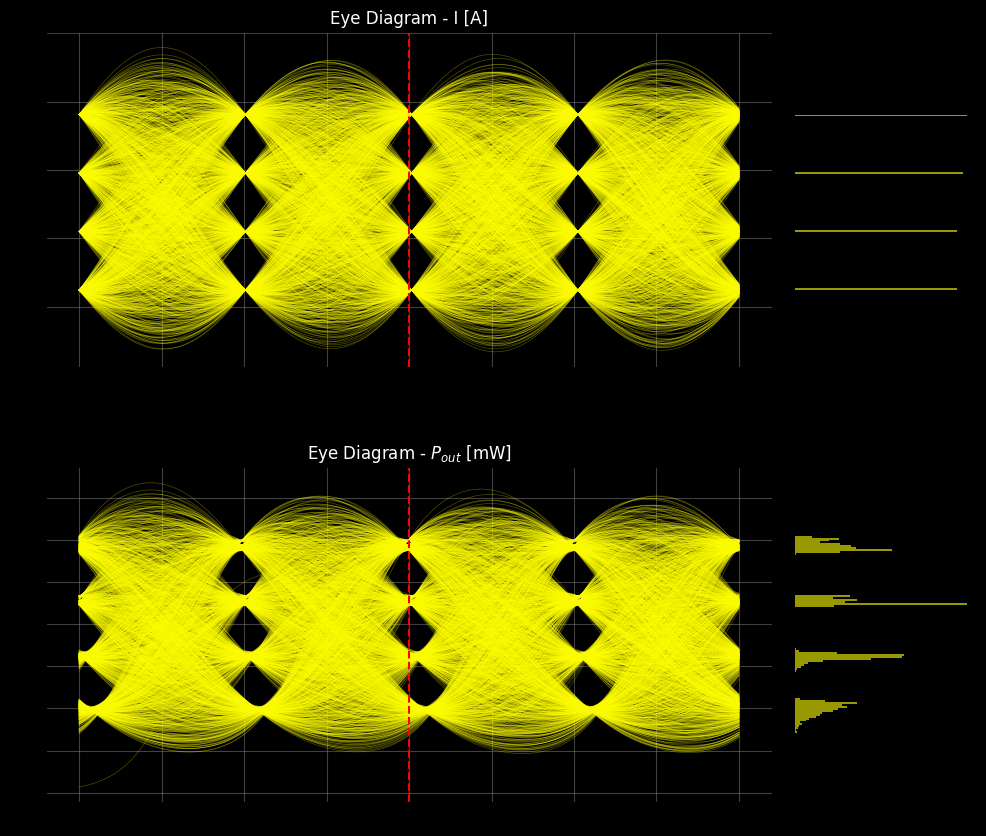

In [5]:
# Importaciones estándar y de ML
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Input
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import time

# Importaciones de tus códigos locales
from params import SOAparams
from soa_main import run_simulation, plot_results, plot_eye_diagrams, plot_single_eye_with_hist

# Instanciar parámetros globales
p = SOAparams()
WINDOW_SIZE = 32

print("Iniciando simulación del SOA...")
# Llamamos a la función de soa_main.py
# I_trim es la corriente ideal (PAM-4)
# P_out_trim es la potencia óptica distorsionada
I_trim, P_out_trim, P_levels, thresholds, off_best = run_simulation()

print("Generando gráficas ANTES del modelo...")

# 1. Gráficas de resultados y los histogramas generados aparte
plot_results(I_trim, P_out_trim, P_levels, thresholds, p.sample_period)

# 2. Los ojos originales y sus histogramas laterales
plot_eye_diagrams(I_trim, P_out_trim, p.samples_per_bit, off_best)

plt.show()

In [6]:
# Creamos el DataFrame mapeando las 4 variables que espera tu modelo Teacher
# Usamos getattr por si Bit_Rate no está directo en p, pero puedes ajustar los valores fijos.
df = pd.DataFrame({
    'Time_s': np.arange(len(I_trim)) * p.sample_period,
    'Current_Input_A': I_trim,                 # Target (y)
    'Power_Output_mW': P_out_trim * 1e3,       # Feature 1: Potencia distorsionada
    'Bit_Rate': getattr(p, 'bit_rate', 50e9),  # Feature 2: Tasa de bits (ajusta si es necesario)
    'Beta_RC': 0.3,                            # Feature 3: Roll-off del Raised Cosine
    'Rango_Corr': 0.4                          # Feature 4: Imax(0.65) - Imin(0.25)
})

def load_and_prep_data(df, window_size):
    FEATURES = ['Power_Output_mW', 'Bit_Rate', 'Beta_RC', 'Rango_Corr']
    
    # Extraemos las 4 columnas para X
    X_raw = df[FEATURES].values
    y_raw = df['Current_Input_A'].values.reshape(-1, 1)
    
    # Escalamiento
    scaler_X = MinMaxScaler(feature_range=(0, 1))
    scaler_y = MinMaxScaler(feature_range=(0, 1))
    
    X_scaled = scaler_X.fit_transform(X_raw)
    y_scaled = scaler_y.fit_transform(y_raw)
    
    # Empaquetado en secuencias
    X_seq, y_seq = [], []
    offset = window_size // 2 
    for i in range(len(X_scaled) - window_size):
        X_seq.append(X_scaled[i : i + window_size])
        y_seq.append(y_scaled[i + offset])
        
    return np.array(X_seq), np.array(y_seq), scaler_X, scaler_y

X, y, scaler_X, scaler_y = load_and_prep_data(df, WINDOW_SIZE)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [7]:
from tensorflow.keras import layers, models, backend as K

# --- COMPONENTES PERSONALIZADOS ---
@tf.keras.utils.register_keras_serializable()   
def combined_loss(y_true, y_pred):
    mse = K.mean(K.square(y_true - y_pred))
    mae = K.mean(K.abs(y_true - y_pred))
    return 0.7 * mse + 0.3 * mae

@tf.keras.utils.register_keras_serializable()
class SimpleAttention(layers.Layer):
    def __init__(self, units, **kwargs):
        super(SimpleAttention, self).__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        self.W = layers.Dense(self.units, activation='tanh')
        self.V = layers.Dense(1)
        super(SimpleAttention, self).build(input_shape)

    def call(self, inputs):
        score = self.V(self.W(inputs))
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = attention_weights * inputs
        return context_vector

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units})
        return config

# --- ARQUITECTURA DEL MODELO TEACHER ---
def build_teacher_model(window_size, num_features):
    inputs = layers.Input(shape=(window_size, num_features))

    # Bloque 1: ADCNN (Dilatación)
    c = layers.Conv1D(64, kernel_size=5, padding='same', activation='relu')(inputs)
    c = layers.BatchNormalization()(c)
    c = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu', dilation_rate=2, name='conv_intermediate')(c)
    c = layers.MaxPooling1D(pool_size=2)(c) 

    # Bloque 2: BiGRU con Atención
    r = layers.Bidirectional(layers.GRU(64, return_sequences=True), name='bigru_intermediate')(c)
    a = SimpleAttention(128)(r)
    a = layers.GlobalAveragePooling1D()(a)

    # Bloque 3: Refinamiento Residual
    dense_base = layers.Dense(64, activation='relu')(a)
    res = layers.Dense(64, activation='relu')(dense_base)
    res = layers.Dense(64, activation='relu')(res)
    combined = layers.Add()([dense_base, res])

    # Salida
    x = layers.Dense(32, activation='relu')(combined)
    x = layers.Dropout(0.1)(x)
    outputs = layers.Dense(1, activation='linear')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="Teacher_SOA_ResNet")
    model.compile(optimizer=Adam(learning_rate=0.001), loss=combined_loss)
    return model

# Usamos NUM_FEATURES = 1 para este notebook
NUM_FEATURES = 4    
model = build_teacher_model(WINDOW_SIZE, NUM_FEATURES)
model.summary()

Model: "Teacher_SOA_ResNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 32, 64)    │      1,344 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_intermediate   │ (None, 32, 64)    │     12,352 │ batch_normalizat… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 16, 64)    │          0 │ conv_intermediat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bigru_intermediate  │ (None, 16, 128)   │     49,920 │ max_pooling1d[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_attention    │ (None, 16, 128)   │     16,641 │ bigru_intermedia… │
│ (SimpleAttention)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ simple_attention… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      4,160 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      4,160 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64)        │          0 │ dense_2[0][0],    │
│                     │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │      2,080 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         33 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 99,202 (387.51 KB)

 Trainable params: 99,074 (387.01 KB)

 Non-trainable params: 128 (512.00 B)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint('teacher_best_weights.keras', save_best_only=True, monitor='val_loss')
]

print("Entrenando Modelo Teacher...")
t_train = time.time()   
history = model.fit(
    X_train, y_train,
    epochs=15, # Puedes subirlo a 60 como en tu script original si gustas
    batch_size=256, 
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)
print(f"Tiempo de entrenamiento: {(time.time() - t_train):.2f} s")

print("Realizando inferencia con los datos de prueba...")
y_pred_scaled = model.predict(X_test)

# Desescalar
y_pred_unaligned = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_true_unaligned = scaler_y.inverse_transform(y_test).flatten()

# Corrección de desfase para mantener sincronía con el centro del ojo (samples_per_bit)
test_start_index = len(X_train) + (WINDOW_SIZE // 2)
shift = (p.samples_per_bit - (test_start_index % p.samples_per_bit)) % p.samples_per_bit

y_pred = y_pred_unaligned[shift:]
y_true = y_true_unaligned[shift:]

Entrenando Modelo Teacher...
Epoch 1/15
738/738 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - loss: 0.0187 - val_loss: 0.0084 - learning_rate: 0.0010
Epoch 2/15
738/738 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - loss: 0.0103 - val_loss: 0.0090 - learning_rate: 0.0010
Epoch 3/15
738/738 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - loss: 0.0082 - val_loss: 0.0029 - learning_rate: 0.0010
Epoch 4/15
738/738 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - loss: 0.0072 - val_loss: 0.0041 - learning_rate: 0.0010
Epoch 5/15
738/738 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - loss: 0.0066 - val_loss: 0.0089 - learning_rate: 0.0010
Epoch 6/15
738/738 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - loss: 0.0064 - val_loss: 0.0032 - learning_rate: 0.0010
Epoch 7/15
736/738 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0062
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
738/738 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - loss: 0.0063 - val_loss: 0.0053 - learning_rate: 0.0010
Epoch 8/15
738/738 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step

In [9]:
from sklearn.cluster import KMeans

# Extraemos muestras en el centro del ojo para y_pred y y_true
UI = p.samples_per_bit
offset = UI // 2
centers = np.arange(offset, len(y_pred), UI)

P_samp_true = y_true[centers]
P_samp_pred = y_pred[centers]

# Usamos KMeans para agrupar en EXACTAMENTE 4 niveles (PAM-4) 
# y evitar variaciones causadas por el filtro gaussiano
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10).fit(P_samp_true.reshape(-1, 1))
labels = kmeans.labels_

# Ordenamos los clusters del nivel de corriente más bajo al más alto
cluster_means = [np.mean(P_samp_true[labels == i]) for i in range(4)]
sorted_clusters = np.argsort(cluster_means)

# Guardamos los niveles predichos respetando el orden (del nivel 0 al 3)
P_levels_pred = [P_samp_pred[labels == i] for i in sorted_clusters]

mu = np.array([np.mean(lvl) for lvl in P_levels_pred])
sg = np.array([np.std(lvl) for lvl in P_levels_pred])

# Umbrales dinámicos basados en la predicción de la red
Th1_nn = (sg[0]*mu[1] + sg[1]*mu[0]) / (sg[0] + sg[1])
Th2_nn = (sg[1]*mu[2] + sg[2]*mu[1]) / (sg[1] + sg[2])
Th3_nn = (sg[2]*mu[3] + sg[3]*mu[2]) / (sg[2] + sg[3])

# Clasificar símbolos predichos (valores 1, 2, 3, 4)
sym_hat = np.zeros_like(P_samp_pred)
sym_hat[P_samp_pred < Th1_nn] = 1
sym_hat[(P_samp_pred >= Th1_nn) & (P_samp_pred < Th2_nn)] = 2
sym_hat[(P_samp_pred >= Th2_nn) & (P_samp_pred < Th3_nn)] = 3
sym_hat[P_samp_pred >= Th3_nn] = 4

# Generar los símbolos reales (tx) a partir de los clusters ordenados ideales
sym_tx = np.zeros_like(labels)
for new_idx, original_cluster in enumerate(sorted_clusters):
    sym_tx[labels == original_cluster] = new_idx + 1

SER_nn = np.mean(sym_hat != sym_tx)

# Mapeo Gray inverso para BER
def sym2bits(s_arr):
    b2 = (s_arr == 2) | (s_arr == 3)
    b1 = (s_arr == 1) | (s_arr == 2)
    return np.column_stack((b2, b1)).ravel()

bits_tx = sym2bits(sym_tx)
bits_hat = sym2bits(sym_hat)
BER_nn = np.mean(bits_tx != bits_hat)

print("--- RESULTADOS DESPUÉS DEL MODELO TEACHER ---")
# print(f"SER = {SER_nn:.3e} (errores={np.sum(sym_hat != sym_tx)} de {len(sym_tx)})")
print(f"BER = {BER_nn:.3e} (errores={np.sum(bits_tx != bits_hat)} de {len(bits_tx)})")

--- RESULTADOS DESPUÉS DEL MODELO TEACHER ---
BER = 0.000e+00 (errores=0 de 3274)


c:\Users\natan\anaconda3\envs\env1\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


👁️ Generando Comparativa de Diagramas de Ojo e Histogramas...


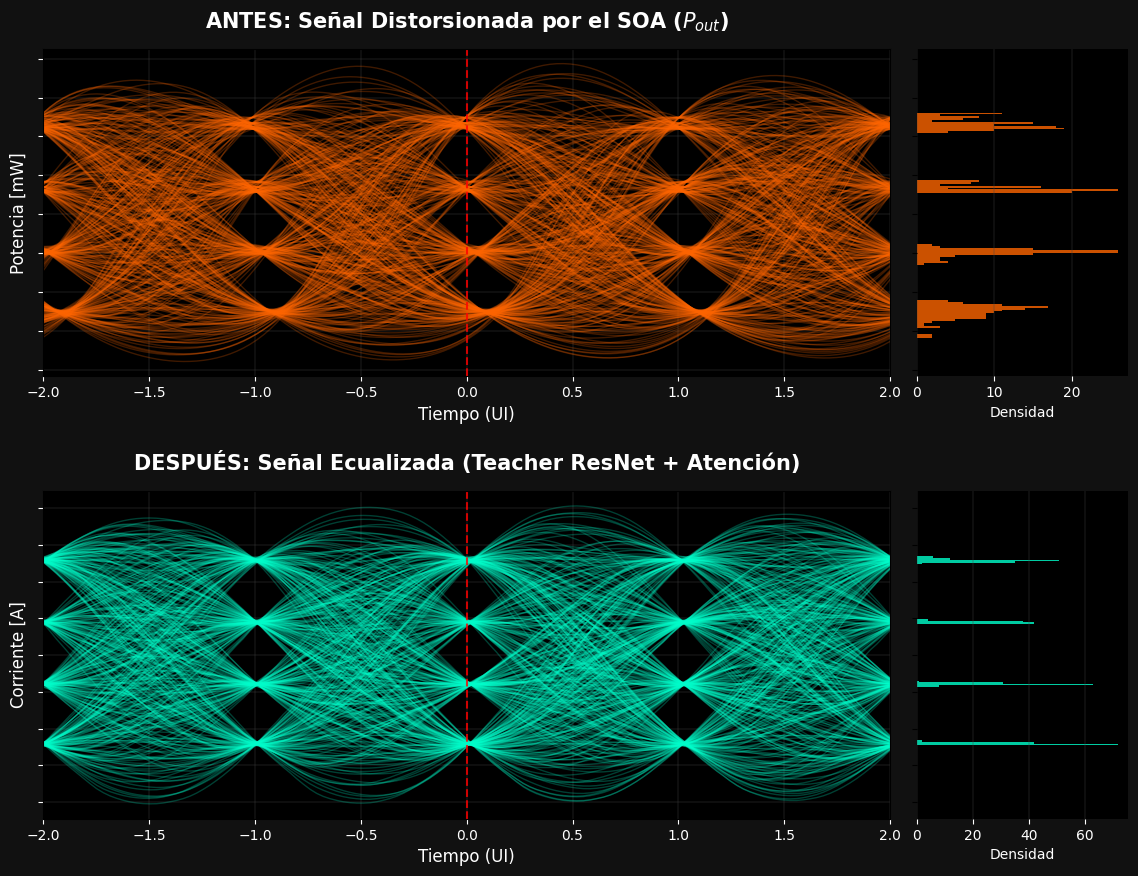

In [11]:
# ==========================================
# CELDA: DIAGRAMAS DE OJO ULTRA HD (ANTES VS DESPUÉS)
# ==========================================
import matplotlib.gridspec as gridspec

# 1. Extraemos la señal distorsionada alineada exactamente con nuestras predicciones
P_out_test_aligned = df['Power_Output_mW'].values[test_start_index + shift : test_start_index + shift + len(y_pred)]

# 2. Función de graficado de alta calidad (Estilo Osciloscopio Profesional)
def plot_comparativa_ojos(distorsionada, recuperada, UI):
    offset = UI // 2
    
    # Fondo oscuro elegante para resaltar los colores neón
    fig = plt.figure(figsize=(14, 10), facecolor='#111111') 
    gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], wspace=0.05, hspace=0.35)
    
    def draw_eye_hist(ax_eye, ax_hist, signal, title, ylabel, color):
        span_ui = 4 
        samples_per_span = span_ui * UI
        signal_shifted = signal[offset:]
        n_traces = len(signal_shifted) // samples_per_span
        
        if n_traces == 0: return
            
        signal_cut = signal_shifted[:n_traces * samples_per_span]
        eye_matrix = signal_cut.reshape((n_traces, samples_per_span))
        t_span = np.linspace(-span_ui/2, span_ui/2, samples_per_span)
        
        # --- DIBUJAR OJO ---
        ax_eye.plot(t_span, eye_matrix.T, color=color, alpha=0.25, linewidth=1.0)
        ax_eye.set_facecolor('#000000')
        ax_eye.set_title(title, color='white', fontsize=15, fontweight='bold', pad=15)
        ax_eye.set_ylabel(ylabel, color='white', fontsize=12)
        ax_eye.set_xlabel('Tiempo (UI)', color='white', fontsize=12)
        ax_eye.tick_params(axis='x', colors='white')
        ax_eye.tick_params(axis='y', colors='white')
        ax_eye.set_xlim([-span_ui/2, span_ui/2])
        
        # Cuadrícula sutil
        ax_eye.grid(True, which='both', linestyle='-', linewidth=0.3, color='#444444')
        ax_eye.axvline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.8) 

        # --- DIBUJAR HISTOGRAMA LATERAL ---
        center_idx = samples_per_span // 2
        samples_at_center = eye_matrix[:, center_idx]
        
        ax_hist.hist(samples_at_center, bins=120, color=color, alpha=0.8, orientation='horizontal')
        ax_hist.set_facecolor('#000000')
        ax_hist.tick_params(axis='x', colors='white')
        ax_hist.set_yticklabels([]) 
        ax_hist.set_xlabel('Densidad', color='white', fontsize=10)
        ax_hist.grid(True, axis='x', linestyle='-', linewidth=0.3, color='#444444')
        ax_hist.set_ylim(ax_eye.get_ylim())
        
        # Limpiar bordes del histograma
        for spine in ax_hist.spines.values(): spine.set_visible(False)

    # Fila 1: EL DESASTRE (Señal Distorsionada) - Naranja Eléctrico
    ax_eye_1 = plt.subplot(gs[0, 0])
    ax_hist_1 = plt.subplot(gs[0, 1], sharey=ax_eye_1)
    draw_eye_hist(ax_eye_1, ax_hist_1, distorsionada, 
                  'ANTES: Señal Distorsionada por el SOA ($P_{out}$)', 'Potencia [mW]', '#FF6600')

    # Fila 2: LA MAGIA (Señal Recuperada por la IA) - Cian/Verde Neón
    ax_eye_2 = plt.subplot(gs[1, 0])
    ax_hist_2 = plt.subplot(gs[1, 1], sharey=ax_eye_2)
    draw_eye_hist(ax_eye_2, ax_hist_2, recuperada, 
                  'DESPUÉS: Señal Ecualizada (Teacher ResNet + Atención)', 'Corriente [A]', '#00FFCC')
    
    plt.show()

# 3. ¡Disparar la gráfica!
print("👁️ Generando Comparativa de Diagramas de Ojo e Histogramas...")
plot_comparativa_ojos(P_out_test_aligned, y_pred, p.samples_per_bit)